In [61]:
import pandas as pd 
clean_df=pd.read_csv("../data/processed/starlink_clean.csv")
clean_df["Epoch"] = pd.to_datetime(clean_df["Epoch"])


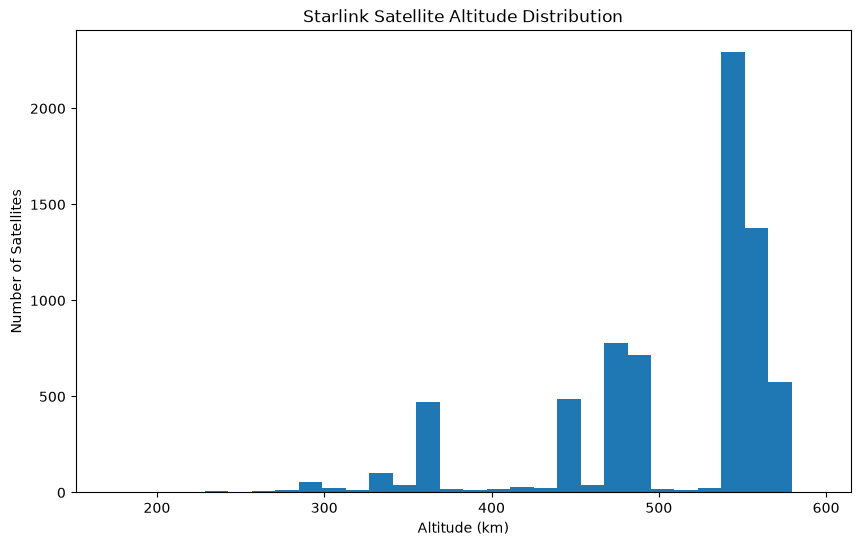

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(clean_df["Altitude_km"],bins=30)
plt.xlabel("Altitude (km)")
plt.ylabel("Number of Satellites")
plt.title("Starlink Satellite Altitude Distribution")

plt.show()

In [62]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7153 entries, 0 to 7152
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   Satellite_Name              7153 non-null   str                
 1   Epoch                       7153 non-null   datetime64[us, UTC]
 2   Latitude                    7153 non-null   float64            
 3   Longitude                   7153 non-null   float64            
 4   Altitude_km                 7153 non-null   float64            
 5   Inclination_deg             7153 non-null   float64            
 6   Eccentricity                7153 non-null   float64            
 7   Mean_Motion_orbits_per_day  7153 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(6), str(1)
memory usage: 544.6 KB


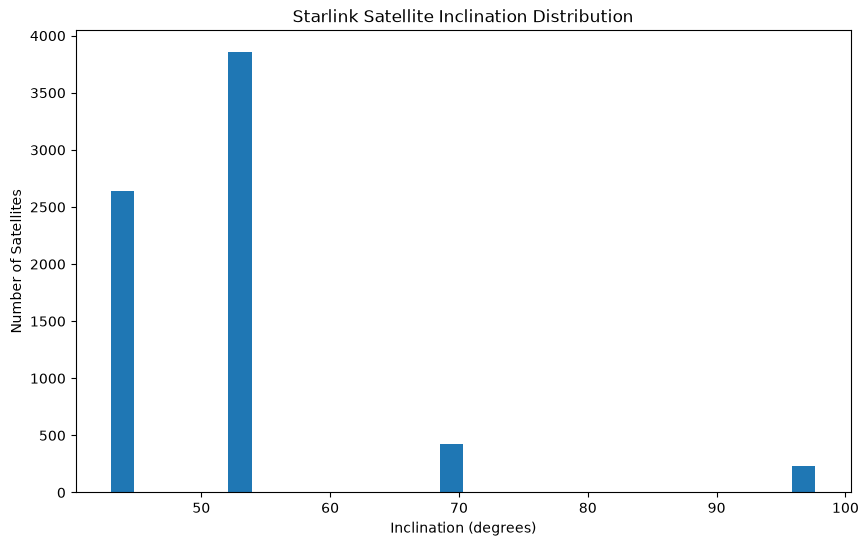

In [63]:
plt.figure(figsize=(10, 6))

plt.hist(clean_df["Inclination_deg"], bins=30)

plt.xlabel("Inclination (degrees)")
plt.ylabel("Number of Satellites")
plt.title("Starlink Satellite Inclination Distribution")

plt.show()

In [65]:
clean_df["Inclination_deg"].round(1).value_counts().sort_index()

Inclination_deg
43.0    2643
53.0     120
53.1     916
53.2    2817
70.0     427
97.6       4
97.7     226
Name: count, dtype: int64

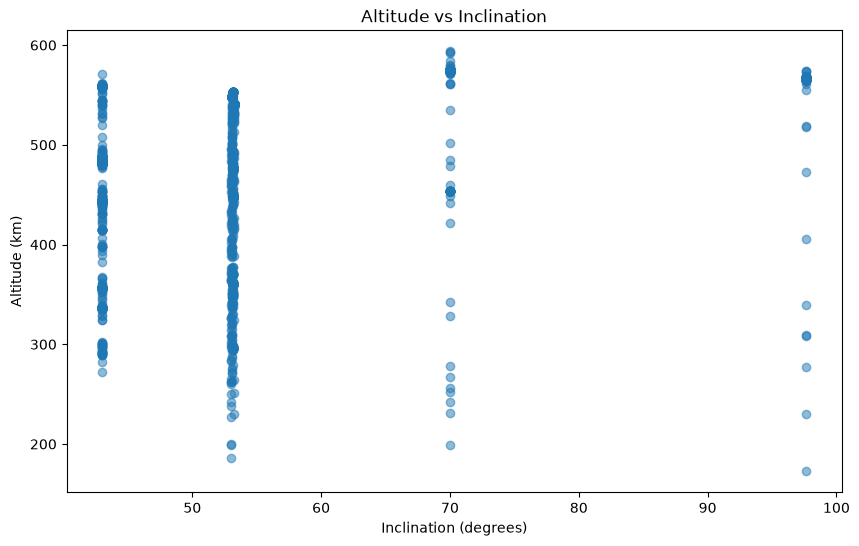

In [70]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df["Inclination_deg"],
    clean_df["Altitude_km"],
    alpha=0.5
)

plt.xlabel("Inclination (degrees)")
plt.ylabel("Altitude (km)")
plt.title("Altitude vs Inclination")

plt.show()

In [71]:
def classify_orbit(inclination):
    if inclination < 60:
        return "Low Inclination"
    elif inclination < 85:
        return "Medium Inclination"
    else:
        return "High Inclination"

In [72]:
clean_df["Orbit_Group"] = clean_df["Inclination_deg"].apply(classify_orbit)

In [73]:
clean_df["Orbit_Group"].value_counts()

Orbit_Group
Low Inclination       6496
Medium Inclination     427
High Inclination       230
Name: count, dtype: int64

In [74]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7153 entries, 0 to 7152
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   Satellite_Name              7153 non-null   str                
 1   Epoch                       7153 non-null   datetime64[us, UTC]
 2   Latitude                    7153 non-null   float64            
 3   Longitude                   7153 non-null   float64            
 4   Altitude_km                 7153 non-null   float64            
 5   Inclination_deg             7153 non-null   float64            
 6   Eccentricity                7153 non-null   float64            
 7   Mean_Motion_orbits_per_day  7153 non-null   float64            
 8   Orbit_Group                 7153 non-null   str                
dtypes: datetime64[us, UTC](1), float64(6), str(2)
memory usage: 706.7 KB


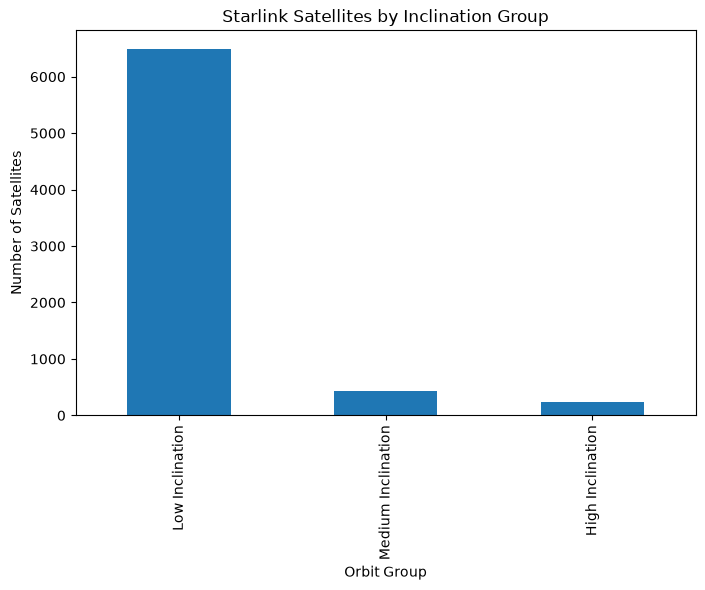

In [80]:
clean_df["Orbit_Group"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Orbit Group")
plt.ylabel("Number of Satellites")
plt.title("Starlink Satellites by Inclination Group")

plt.show()

In [81]:
clean_df.to_csv(
    "../data/processed/starlink_clean.csv",
    index=False
)